# (1+1)D Viscous Burgers Equation with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **viscous Burgers equation** using Physics-Informed Neural Networks (PINNs). The viscous Burgers equation is:

$$\partial_t u + \partial_x \left( \frac{1}{2} u^2 - \nu \partial_x u \right) = 0, \quad \text{for } (t, x) \in [0, 1] \times [-1, 1]$$

which can be written in convective form as:

$$\partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

with initial condition:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

and boundary conditions:
$$u(t, -1) = u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

where:
- $\nu = 0.01/\pi$ is the viscosity coefficient

We will solve this problem using:
1. **Standard PINN**: A single neural network trained on the entire domain
2. **FB-PINN + Temporal Curriculum**: 4×4 domain decomposition with progressive time-window expansion


In [1]:
import pinns

import numpy as np
import matplotlib.pyplot as plt

# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters (viscosity)
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Domain of the Problem

We define the (1+1)D space-time domain $\Omega = [0, 1] \times [-1, 1]$ for $(t, x)$.

In [2]:
# Viscosity coefficient
nu = 0.01 / np.pi

domain = pinns.DomainCubic(
    space=[(-1, 1)],  # x_min, x_max
    time=[0, 1],   # t_min, t_max
)

## Differential Equation

### The PDE Residual
The `burgers_residual` function computes the residual of the viscous Burgers equation. For PINNs, we train the network to minimize this residual:

$$\mathcal{R} = \partial_t u + u \partial_x u - \nu \partial_{xx} u = 0$$

where $\nu = 0.01/\pi$ is the viscosity coefficient.

In [3]:
problem = pinns.ProblemStrong(
    domain,
    output_names=["u"]
)

problem.add_parameter('nu', 0.01 / np.pi)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=0, boundary=0, initial=0, params=['nu'], trainable=[])

In [4]:
# Column convention
def burgers_residual(X, U, params, derivative=None):
    # Get viscosity from params (avoids JAX closure issues)
    nu = params["parameter"]['nu']
    
    # Compute derivatives
    u_t = derivative(U, X, 0, (1,))     # ∂u/∂t
    u_x = derivative(U, X, 0, (0,))     # ∂u/∂x
    u_xx = derivative(U, X, 0, (0, 0))  # ∂²u/∂x²
    
    # Viscous Burgers residual: ∂u/∂t + u·∂u/∂x - ν·∂²u/∂x² = 0
    res = u_t + U * u_x - nu * u_xx

    return res

problem.add_inner(
    burgers_residual
)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=0, initial=0, params=['nu'], trainable=[])

## Initial and Boundary Conditions

For the viscous Burgers problem, we have:

**Initial condition** at $t = 0$:
$$u(0, x) = -\sin(\pi x), \quad \text{for } x \in [-1, 1]$$

**Boundary conditions** (homogeneous Dirichlet):
$$u(t, -1) = 0 \quad \text{and} \quad u(t, 1) = 0, \quad \text{for } t \in [0, 1]$$

In [5]:
import jax.numpy as jnp

# Initial condition: u(0, x) = -sin(πx)
def initial_condition(X):
    x = X[:, 0:1]  # First column is x
    return -jnp.sin(jnp.pi * x)

problem.add_initial(
    initial_condition,
    name="initial",
)

# Boundary conditions: u(t, -1) = 0 and u(t, 1) = 0
problem.add_boundary(
    0.0,
    region="xmin",
    name="xmin",
)
problem.add_boundary(
    0.0,
    region="xmax",
    name="xmax",
)


ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=2, initial=1, params=['nu'], trainable=[])

## Reference Solution (pseudo-spectral adaptive Dopri5)

A high-accuracy reference is computed using `ModelSpectralSolver` + `IntegratorDopri5`
(native adaptive Dormand-Prince 4(5)) on a **DST-1 spectral grid** with homogeneous Dirichlet BCs.

$$\partial_t \hat{u}_k = \underbrace{-\nu k^2 \hat{u}_k}_{\text{linear (exact)}} + \underbrace{\widehat{(-u \partial_x u)}}_{\text{nonlinear (physical-space FD)}}$$

`bc="dirichlet"` uses the Discrete Sine Transform — interior nodes only, zero BCs
at $x = \pm 1$ are implicit in the basis.  The nonlinear term $-u \partial_x u$ is
evaluated in physical space using second-order central differences (matching the
previous `scipy` approach), then transformed back to spectral space.


U_ref shape: (200, 512)   range: [-0.9998, 0.9998]
NaNs: 0


Text(0.5, 1.0, 'Reference solution u(t,x)')

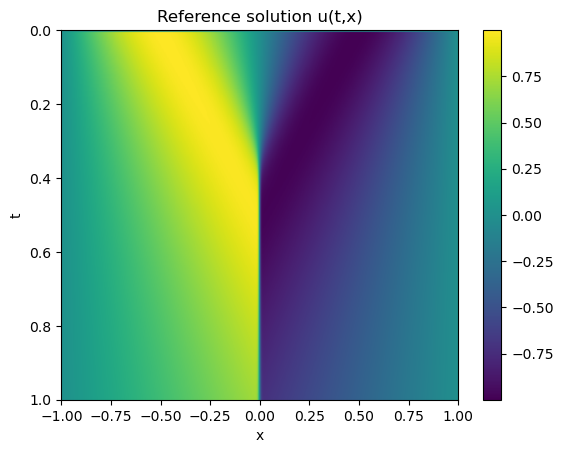

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
Nx  = 512   # interior grid points
Nt  = 200

# ── DomainCubic + ModelSpectralSolver ─────────────────────────────────────────
domain_grid = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, 1.0),
)

integrator_ref = pinns.AdaptiveIntegrator(
    pinns.IntegratorDopri5(),
    dt0=1e-2,
    max_steps=2**12,
)

model_burgers = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator_ref, shape=(Nx,))

# Grid nodes are exposed by ModelSpectralSolver after construction
x_ref = np.array(model_burgers.x)   # (Nx,) interior nodes
dx    = float(x_ref[1] - x_ref[0])

# ── Linear operator: ν ∂²_x  →  −ν k² in spectral space ─────────────────────
model_burgers.set_linear_op(
    lambda X, p: {"u": -p["parameter"]["nu"] * X**2}
)

# ── Nonlinear operator: −u ∂_x u (central FD in physical space) ──────────────
def burgers_nonlinear(X, U, p):
    u     = model_burgers.inverse(U["u"])                       # (Nx,) interior
    u_ext = jnp.concatenate([jnp.zeros(1), u, jnp.zeros(1)])   # ghost BCs
    u_x   = (u_ext[2:] - u_ext[:-2]) / (2.0 * dx)             # central diff ∂_x u
    return {"u": model_burgers.forward(-u * u_x)}

model_burgers.set_source_fn(burgers_nonlinear)
model_burgers.add_parameter("nu", nu)

# ── Initial condition: u(x, 0) = −sin(πx) ────────────────────────────────────
model_burgers.add_initial(-jnp.sin(jnp.pi * jnp.array(x_ref)))

# ── Forward solve — runs once, caches interpolants ────────────────────────────
U_sol  = model_burgers.solve()
U_ref  = np.array(U_sol["u"])   # (Nt, Nx) for plotting

# ── Reference callable: predict(X) interpolates without re-solving ────────────
u_reference = model_burgers.predict   # function, not array

# ── Quick plot ────────────────────────────────────────────────────────────────
plt.imshow(U_ref, extent=(-1, 1, 1, 0), aspect='auto', cmap='viridis')
plt.colorbar(); plt.xlabel("x"); plt.ylabel("t"); plt.title("Reference solution u(t,x)")


# Solve with Standard PINN

## Network Architecture

We use a **Fully Connected Neural Network (FNN)** with:
- **Architecture**: [2, 256, 256, 1] - 2 inputs (t, x), two hidden layers with 256 neurons each, 1 output (u)
- **Activation**: `tanh` - smooth activation suitable for learning smooth physical solutions
- **normalize_input**: `True` - inputs are normalized to improve training
- **unnormalize_output**: `True` - outputs are denormalized using the specified output range

In [7]:
network = pinns.create_model(
    domain, 2,
    features=pinns.FourierFeatures(64),
    core=pinns.FNN([128, 128, 128], activation="tanh"),
)

## Training Configuration

The trainer is configured with:
- **train_samples**: 5000 PDE points, 100 points for initial condition, 100 points per boundary
- **test_samples**: 5000 PDE points for testing
- **weights**: Equal weighting (1.0) for all loss terms
- **optimizer**: Adam with learning rate $10^{-3}$
- **epochs**: 10,000 training iterations
- **print_each**: Print progress every 1000 epochs

Starting training for 100000 epochs (JIT-compiled)...


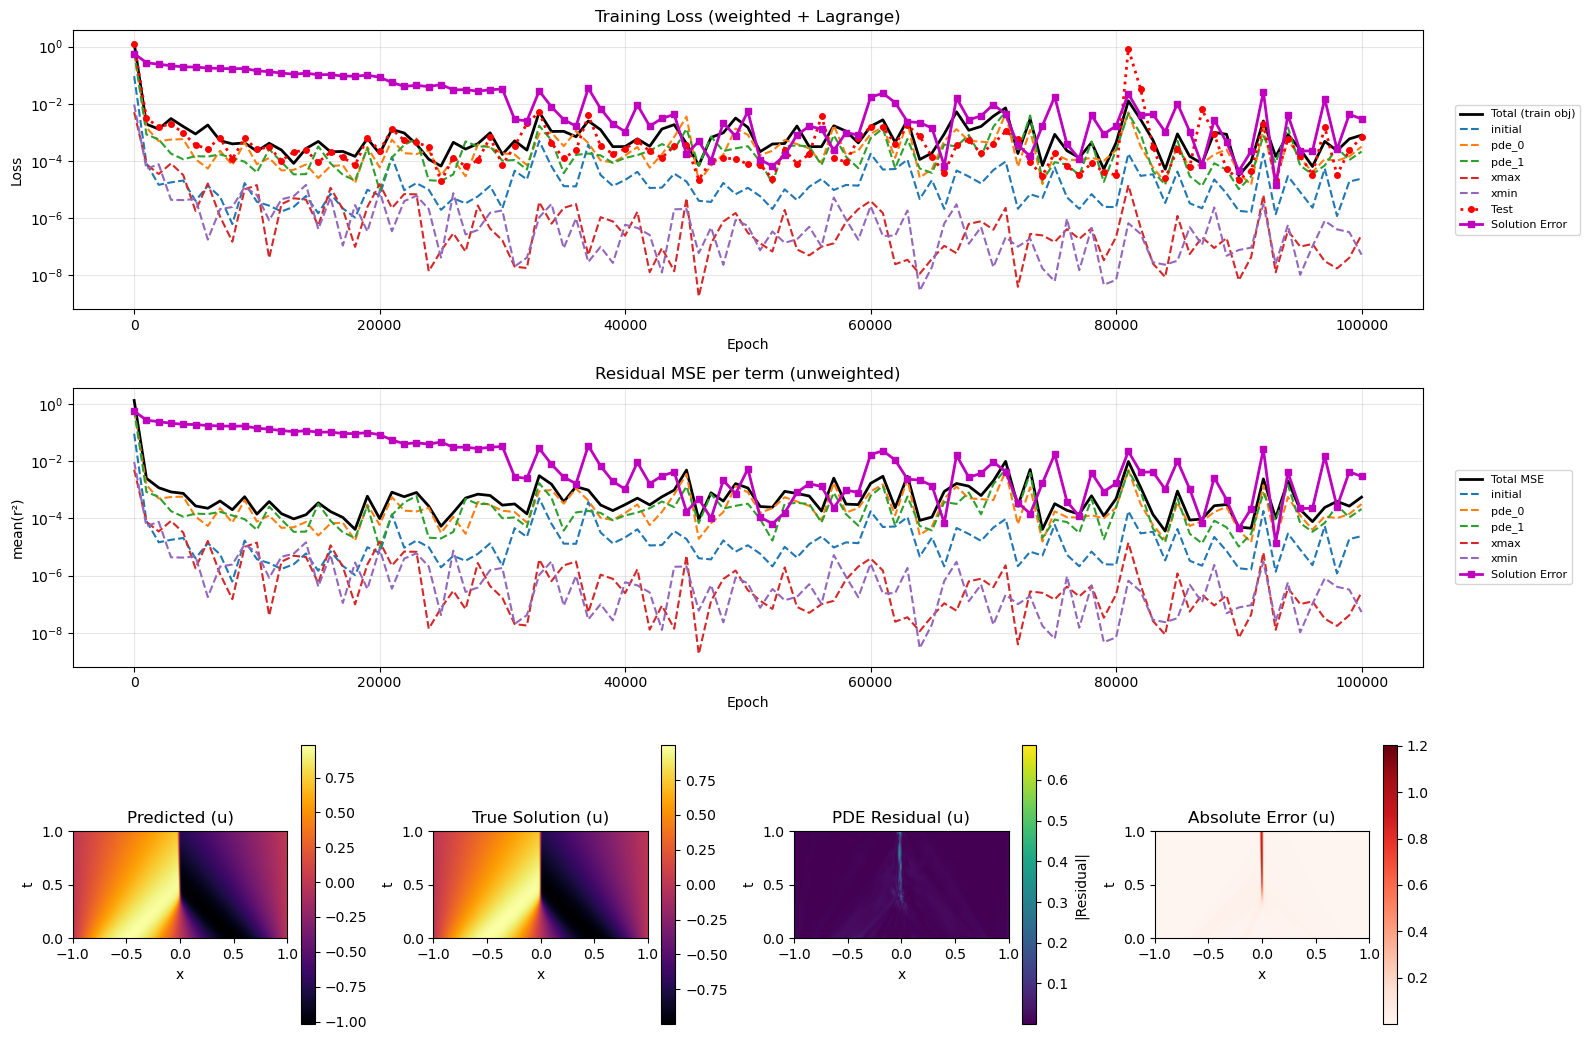

Epoch 0/100000 | Loss: 1.33e+00 | MSE: 1.33e+00 | Terms: [initial: 9.13e-02, pde_0: 5.81e-01, pde_1: 6.41e-01, xmax: 5.03e-03, xmin: 9.35e-03] | Test Loss: 1.23e+00 | Error: 5.60e-01 | Time: 0.0s
Epoch 1000/100000 | Loss: 1.92e-03 | MSE: 2.52e-03 | Terms: [initial: 8.10e-05, pde_0: 1.47e-03, pde_1: 8.39e-04, xmax: 7.60e-05, xmin: 5.32e-05] | Test Loss: 3.11e-03 | Error: 2.73e-01 | Time: 9.7s
Epoch 2000/100000 | Loss: 1.30e-03 | MSE: 1.18e-03 | Terms: [initial: 1.46e-05, pde_0: 4.92e-04, pde_1: 5.64e-04, xmax: 3.48e-05, xmin: 7.60e-05] | Test Loss: 1.53e-03 | Error: 2.39e-01 | Time: 11.8s
Epoch 3000/100000 | Loss: 3.01e-03 | MSE: 8.39e-04 | Terms: [initial: 1.77e-05, pde_0: 5.57e-04, pde_1: 1.79e-04, xmax: 8.12e-05, xmin: 4.35e-06] | Test Loss: 1.97e-03 | Error: 2.13e-01 | Time: 13.9s
Epoch 4000/100000 | Loss: 1.59e-03 | MSE: 7.46e-04 | Terms: [initial: 2.06e-05, pde_0: 5.76e-04, pde_1: 1.14e-04, xmax: 3.19e-05, xmin: 4.24e-06] | Test Loss: 9.40e-04 | Error: 1.94e-01 | Time: 16.0s
Epoch

In [ ]:
trainer = pinns.Trainer(
    problem, network,
)

trainer.set_solution(u_reference)

trainer.compile(
    problem = {
        "pde":      {"train": 5000, "test": 10, "weight": 1.0},
        "initial":  {"train": 200,  "test": 10, "weight": 1.0},
        "xmin": {"train": 200,  "test": 10, "weight": 1.0},
        "xmax": {"train": 200,  "test": 10, "weight": 1.0},
    },
    optimizer=pinns.AdamOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1000),
        pinns.SchedulerCurriculum(
            t_ends=[0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
            epochs_per_stage=10000,
        ),
    ],
    epochs     = 100000,
    print_each = 1000,
)

trainer.train()

# Solve with FB-PINN + Temporal Scheduling

We follow Section 5.2 of the FBPINNs paper:

- **4 × 4 = 16 subdomains** — 4 in $x \in [-1, 1]$, 4 in $t \in [0, 1]$.
- Subdomain breakpoints in $x$: $\{-1,\,-0.5,\,0,\,0.5,\,1\}$ — the interface at $x=0$
  **coincides with the shock**, testing accuracy across the discontinuity.
- **Overlap** `1.8` → window extends 0.2 units past each subdomain edge (total 0.4).
- **Sub-network**: 2 hidden layers × 16 units, `tanh`.
- **Temporal curriculum**: `SchedulerCurriculum` + `SchedulerPartition(window=None)`
  progressively expand both the sampling window and the active set of subnets,
  one time-row at a time.


## Domain Partition and Model


In [9]:
# 4 subdomains in x with a breakpoint exactly at x=0 (shock location)
# 4 subdomains in time: [0,0.25], [0.25,0.5], [0.5,0.75], [0.75,1]
domain.set_partition(
    space=[np.array([-1.0, -0.5, 0.0, 0.5, 1.0])],
    time=4,
)

# Overlap: window extends 0.2 units past each subdomain edge → total overlap 0.4
# spacing_x = 0.5,  overlap = 1 + 2*0.2/0.5 = 1.8
# spacing_t = 0.25, same ratio gives overlap = 1.8
OVERLAP = 1.8

# Sub-network: Normalize → FNN(16, 16, tanh) — 2 hidden layers, 16 units each
template = pinns.ModelBase(domain, output_dim=1)
template.add(pinns.Normalize())
template.add(pinns.FNN([16, 16], activation="tanh"))

network_fb = pinns.ModelPartitioned(template, pinns.PartitionFB(overlap=OVERLAP))
print(network_fb)


ModelPartitioned(shape=4×4, strategy=PartitionFB, n_models=16, output_dim=1)
  ├─ sub_0: PartitionFB(window='hann', overlap=1.8, center=[-0.75, 0.125], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  ├─ sub_1: PartitionFB(window='hann', overlap=1.8, center=[-0.25, 0.125], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  ├─ sub_2: PartitionFB(window='hann', overlap=1.8, center=[0.25, 0.125], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  ├─ sub_3: PartitionFB(window='hann', overlap=1.8, center=[0.75, 0.125], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  ├─ sub_4: PartitionFB(window='hann', overlap=1.8, center=[-0.75, 0.375], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  ├─ sub_5: PartitionFB(window='hann', overlap=1.8, center=[-0.25, 0.375], wmin=[0.9, 0.45], wmax=[0.9, 0.45])
  └─ … (10 more)


## Training with Temporal Curriculum

Two schedulers work together at `EPOCHS_PER_STAGE = 20000` boundaries:

| Scheduler | Role |
|-----------|------|
| `SchedulerCurriculum` | Restricts **sampling** to the active time window |
| `SchedulerPartition(group_by_time=True, window=None)` | Activates all spatial subnets of the next time row together (cumulative) |

`group_by_time=True` groups subnets by their shared `t_min` value — so all 4 x-subnets at a given time row are treated as one stage and activated simultaneously:

```
Epoch     0: {sub_0, sub_1, sub_2, sub_3} active   sampling t ∈ [0, 0.25]
Epoch 20000: + {sub_4..7}                           sampling t ∈ [0, 0.50]
Epoch 40000: + {sub_8..11}                          sampling t ∈ [0, 0.75]
Epoch 60000: + {sub_12..15}  (all 16 active)        sampling t ∈ [0, 1.00]
```


Starting training for 100000 epochs (JIT-compiled)...


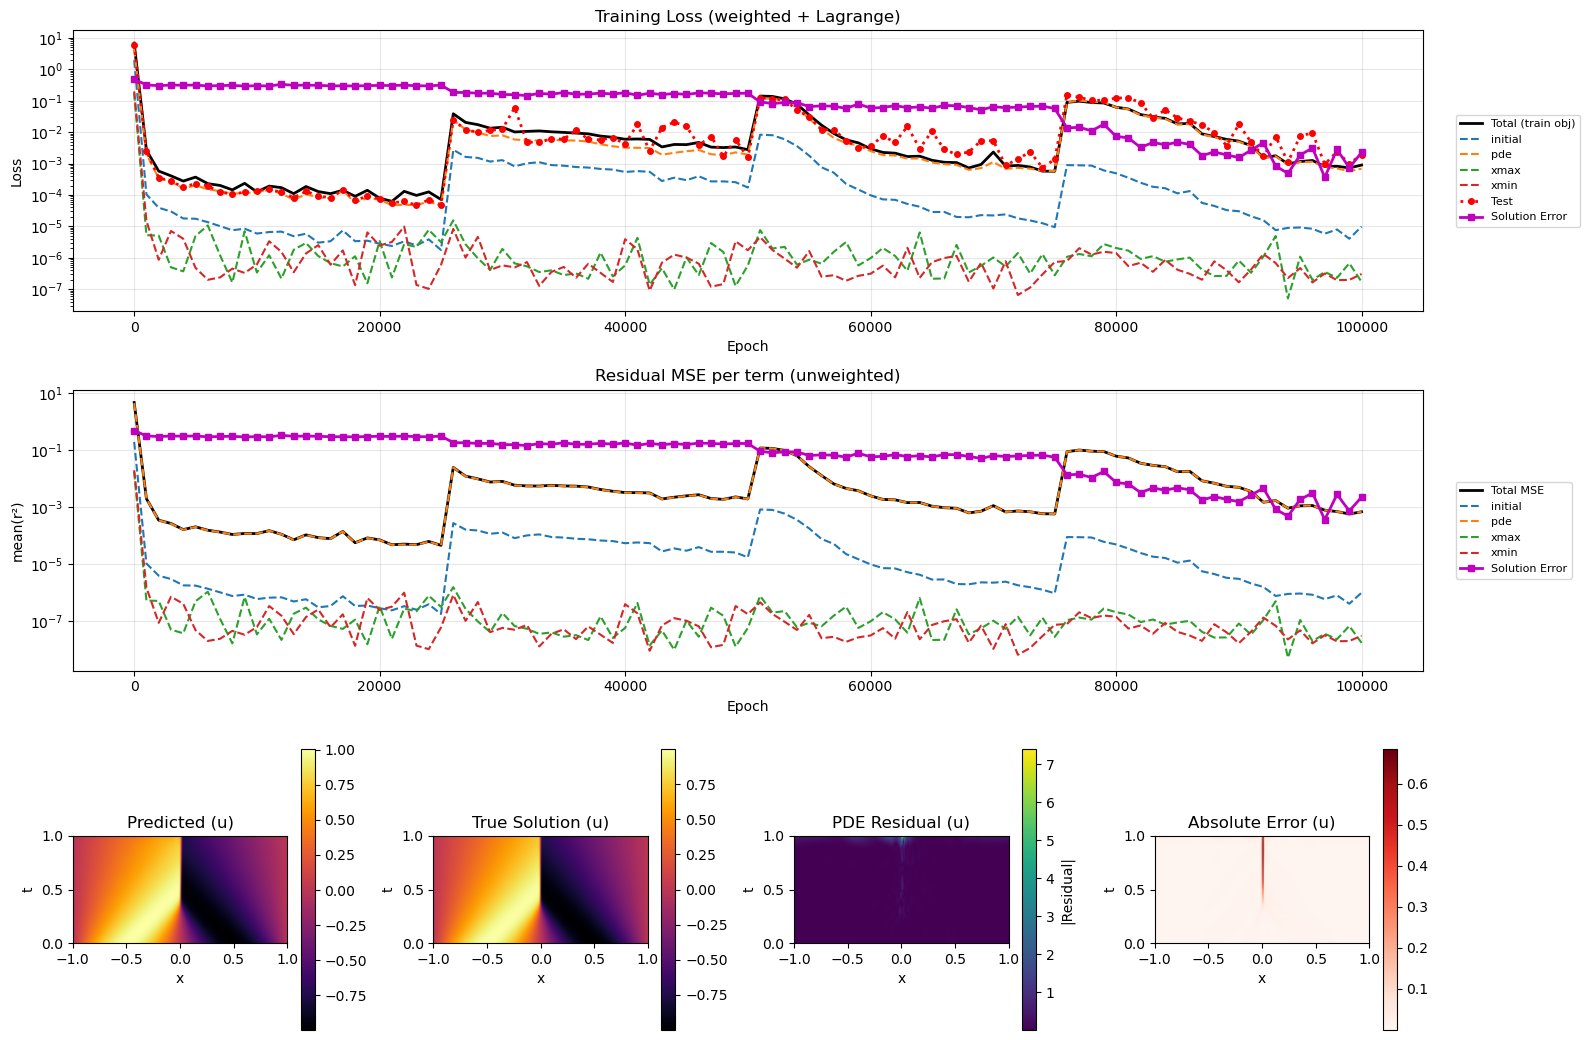

Epoch 0/100000 | Loss: 6.83e+00 | MSE: 4.73e+00 | Terms: [initial: 1.96e-01, pde: 4.50e+00, xmax: 1.76e-02, xmin: 1.98e-02] | Test Loss: 6.03e+00 | Error: 4.85e-01 | Time: 0.0s
Epoch 1000/100000 | Loss: 2.65e-03 | MSE: 1.98e-03 | Terms: [initial: 1.05e-05, pde: 1.97e-03, xmax: 5.24e-07, xmin: 1.49e-06] | Test Loss: 2.46e-03 | Error: 3.19e-01 | Time: 15.2s
Epoch 2000/100000 | Loss: 5.77e-04 | MSE: 3.48e-04 | Terms: [initial: 3.91e-06, pde: 3.43e-04, xmax: 5.09e-07, xmin: 8.65e-08] | Test Loss: 3.57e-04 | Error: 3.01e-01 | Time: 18.4s
Epoch 3000/100000 | Loss: 4.06e-04 | MSE: 2.67e-04 | Terms: [initial: 2.98e-06, pde: 2.63e-04, xmax: 4.97e-08, xmin: 7.13e-07] | Test Loss: 2.74e-04 | Error: 3.15e-01 | Time: 21.7s
Epoch 4000/100000 | Loss: 2.76e-04 | MSE: 1.63e-04 | Terms: [initial: 1.79e-06, pde: 1.61e-04, xmax: 3.71e-08, xmin: 4.04e-07] | Test Loss: 1.76e-04 | Error: 3.11e-01 | Time: 25.0s
Epoch 5000/100000 | Loss: 3.70e-04 | MSE: 2.04e-04 | Terms: [initial: 1.75e-06, pde: 2.02e-04, xmax

In [ ]:
trainer_fb = pinns.Trainer(network_fb, problem=problem)

trainer_fb.set_solution(u_reference)

EPOCHS_PER_STAGE = 25000

trainer_fb.compile(
    problem={
        "pde":     {"train": 5000, "test": 500,  "weight": 1.0},
        "initial": {"train": 200,  "test": 50,   "weight": 10.0},
        "xmin":    {"train": 200,  "test": 50,   "weight": 10.0},
        "xmax":    {"train": 200,  "test": 50,   "weight": 10.0},
    },
    optimizer=pinns.AdamOptimizer(),
    epochs=100000,
    print_each=1000,
    schedulers=[
        pinns.SchedulerResample(100),
        pinns.SchedulerCausal(),
        pinns.SchedulerPartition(
            epochs_per_partition=EPOCHS_PER_STAGE,
            window=None,   # cumulative — never re-freeze
        ),
    ],
)

trainer_fb.train()
